<a href="https://colab.research.google.com/github/szabeebzaliz7-a11y/Datascience-And-Gen-AI/blob/main/Deep_Learning_Module_End_Assessment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Deep Learning Module End

Objective:
You are required to model the progression of diabetes using the available independent
variables. This model will help healthcare professionals understand how different factors
influence the progression of diabetes and potentially aid in designing better treatment
plans and preventive measures. The model will provide insights into the dynamics of
diabetes progression in patients.

Dataset: Use the Diabetes dataset available in the sklearn library.
Key components to be fulfilled :
1. Loading and Preprocessing (4 marks)
● Load the Diabetes dataset from sklearn.
● Handle any missing values if present.
● Normalize the features to ensure better performance of the ANN model.
2. Exploratory Data Analysis (EDA) (4 marks)
● Perform EDA to understand the distribution of features and the target
variable.
● Visualize the relationships between features and the target variable.
3. Building the ANN Model (4 marks)
● Design a simple ANN architecture with at least one hidden layer.
● Use appropriate activation functions .
4. Training the ANN Model (4 marks)
● Split the dataset into training and testing sets.
● Train the model on the training data.
● Use an appropriate loss function and optimizer.
5. Evaluating the Model (3 marks)
● Evaluate the model on the testing data.
● Report the performance metrics (e.g., Mean Squared Error, R2 Score).
6. Improving the Model (5 marks)
○ Experiment with different architectures, activation functions, or
hyperparameters to improve the model performance.
○ Report the changes made and the corresponding improvement in
performance.

## 1. Loading and Preprocessing

In [2]:
from sklearn.datasets import load_diabetes
import pandas as pd

# Load the Diabetes dataset
diabetes = load_diabetes()
X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = pd.Series(diabetes.target, name='progression')

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)
display(X.head())
display(y.head())

Features (X) shape: (442, 10)
Target (y) shape: (442,)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


,progression
0,151.0
1,75.0
2,141.0
3,206.0
4,135.0


### Handle missing values

In [3]:
# Check for missing values
print("Missing values in features:\n", X.isnull().sum())
print("\nMissing values in target:\n", y.isnull().sum())

# The diabetes dataset from sklearn is known to not have missing values, so no imputation is typically needed.

Missing values in features:
 age    0
sex    0
bmi    0
bp     0
s1     0
s2     0
s3     0
s4     0
s5     0
s6     0
dtype: int64

Missing values in target:
 0


### Normalize the features

In [4]:
from sklearn.preprocessing import StandardScaler

# Initialize StandardScaler
scaler = StandardScaler()

# Normalize the features
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print("Scaled features (X_scaled) shape:", X_scaled.shape)
display(X_scaled.head())

Scaled features (X_scaled) shape: (442, 10)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.800500,1.065488,1.297088,0.459841,-0.929746,-0.732065,-0.912451,-0.054499,0.418531,-0.370989
1,-0.039567,-0.938537,-1.082180,-0.553505,-0.177624,-0.402886,1.564414,-0.830301,-1.436589,-1.938479
2,1.793307,1.065488,0.934533,-0.119214,-0.958674,-0.718897,-0.680245,-0.054499,0.060156,-0.545154
3,-1.872441,-0.938537,-0.243771,-0.770650,0.256292,0.525397,-0.757647,0.721302,0.476983,-0.196823
4,0.113172,-0.938537,-0.764944,0.459841,0.082726,0.327890,0.171178,-0.054499,-0.672502,-0.980568


## 2. Exploratory Data Analysis (EDA)

### Distribution of Features and Target Variable

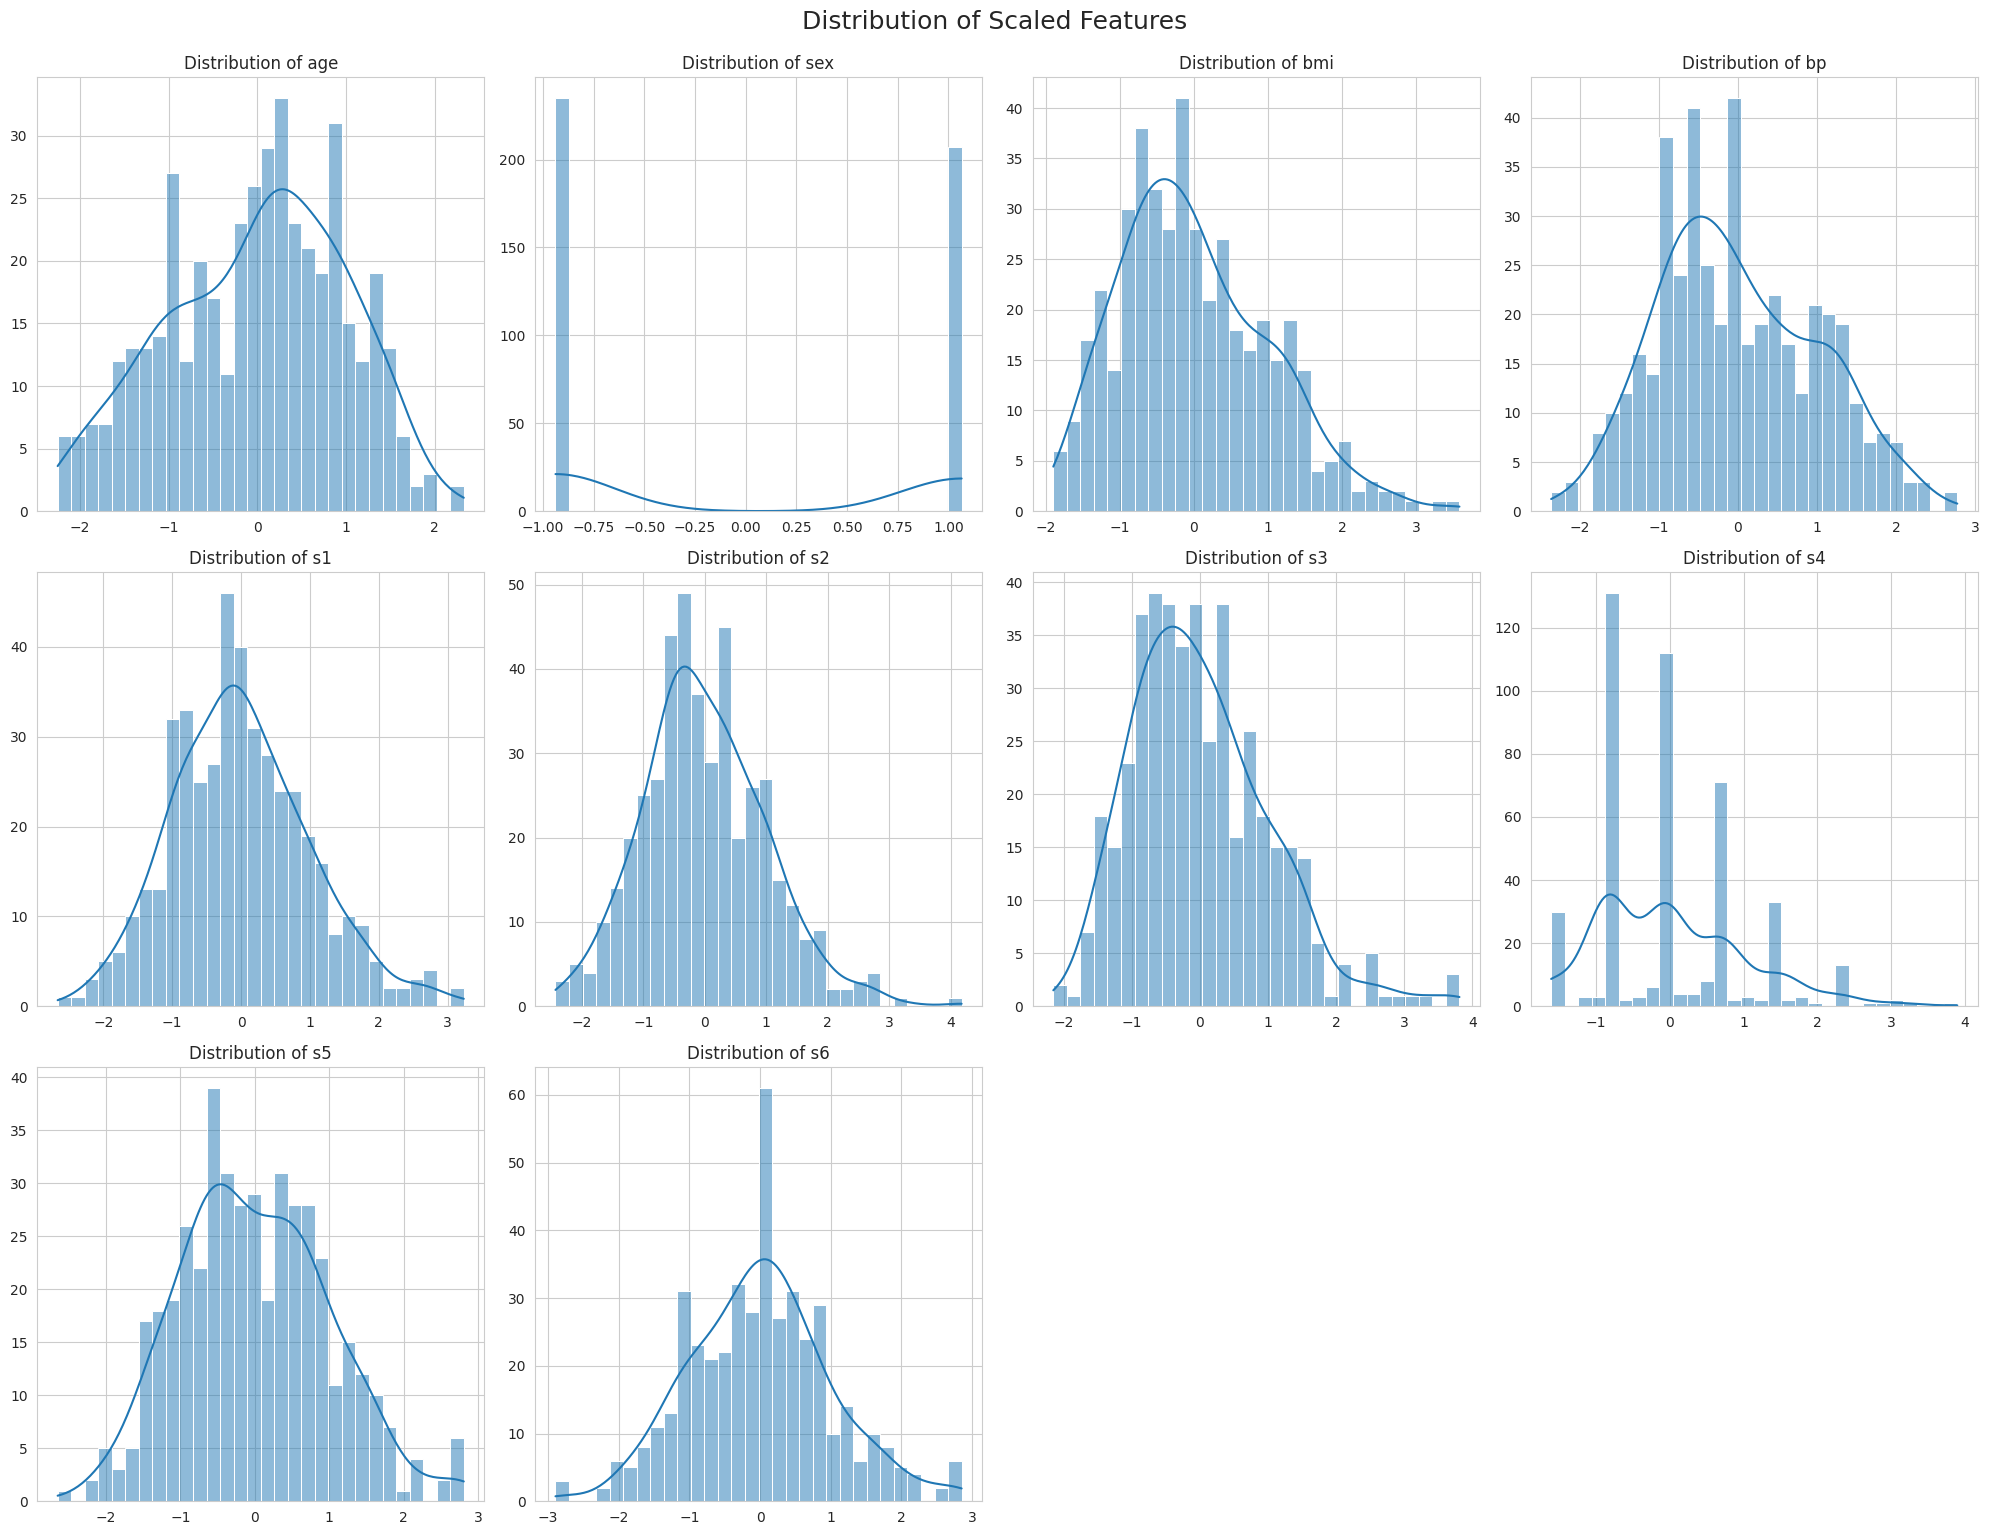

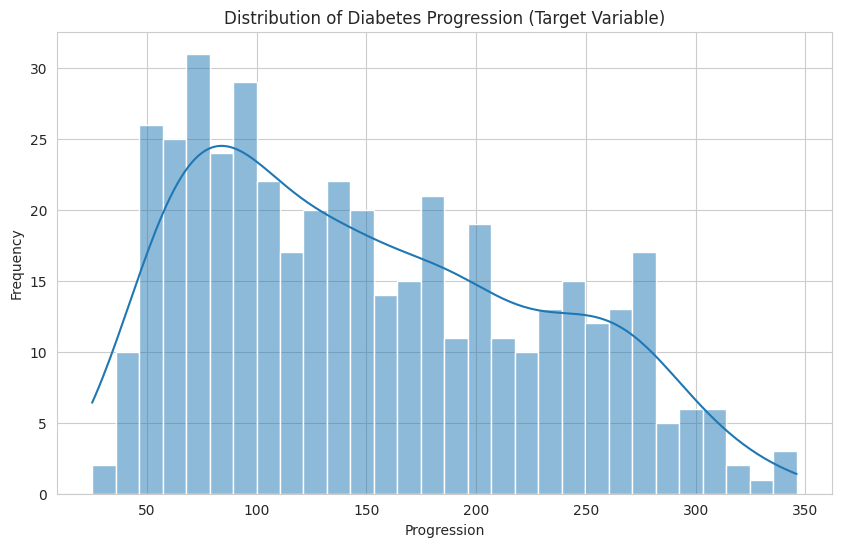

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for plots
sns.set_style('whitegrid')

# Plot distributions of features
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(20, 15))
axes = axes.flatten()

for i, col in enumerate(X_scaled.columns):
    sns.histplot(X_scaled[col], kde=True, ax=axes[i], bins=30)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

# Remove any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('Distribution of Scaled Features', y=1.02, fontsize=18)
plt.show()

# Plot distribution of the target variable
plt.figure(figsize=(10, 6))
sns.histplot(y, kde=True, bins=30)
plt.title('Distribution of Diabetes Progression (Target Variable)')
plt.xlabel('Progression')
plt.ylabel('Frequency')
plt.show()

### Relationships between Features and Target Variable

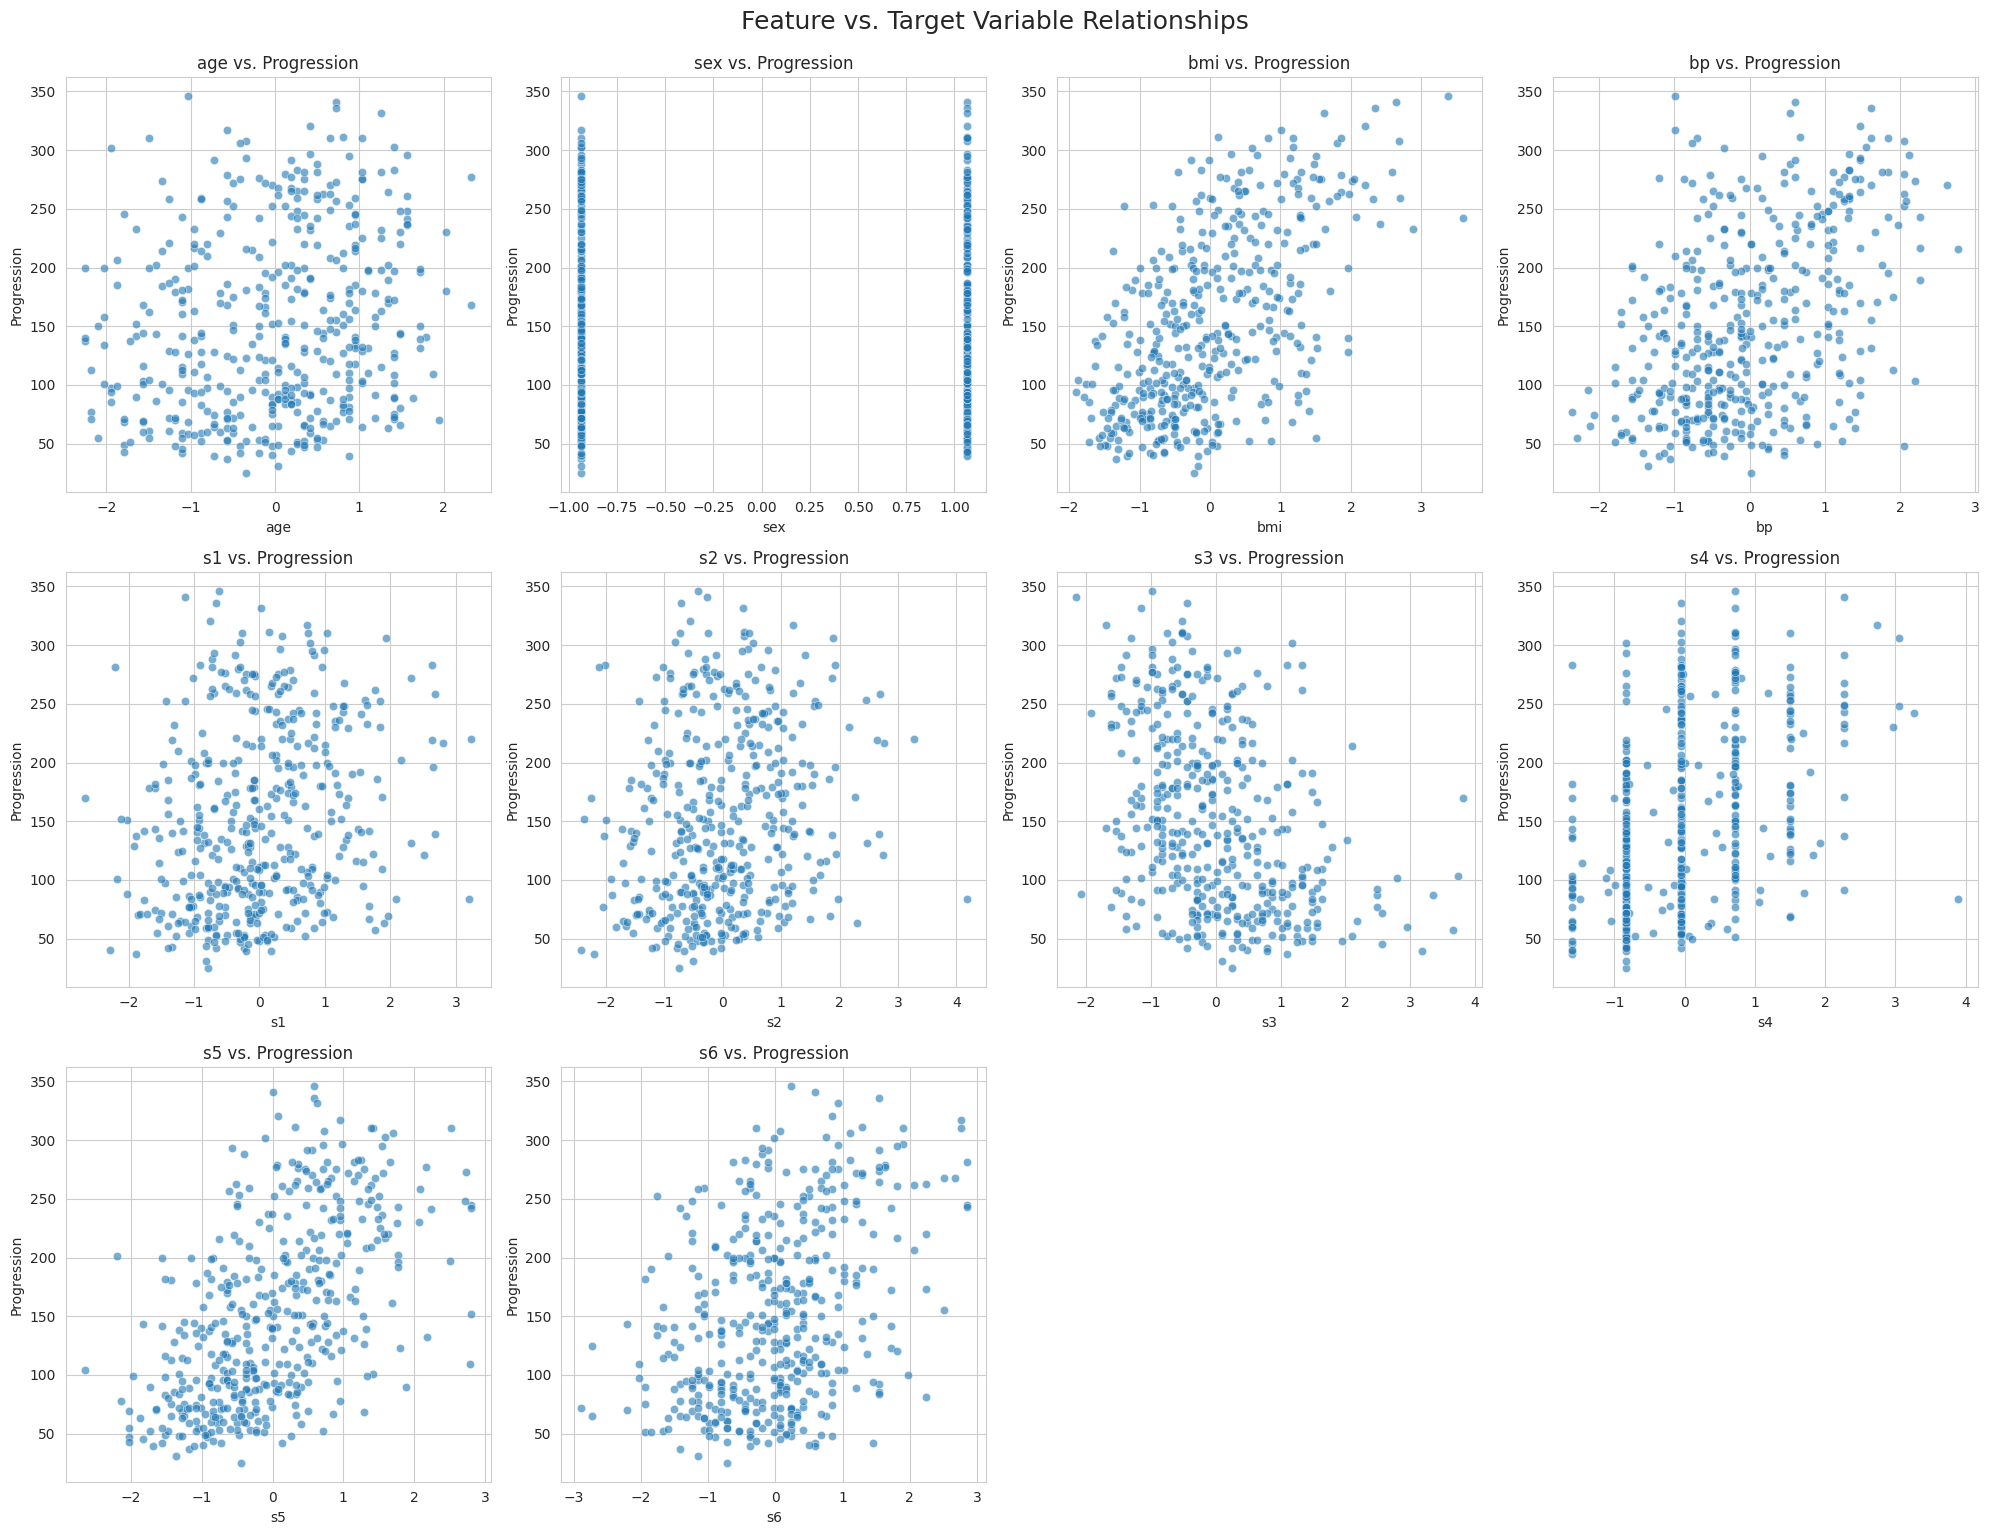

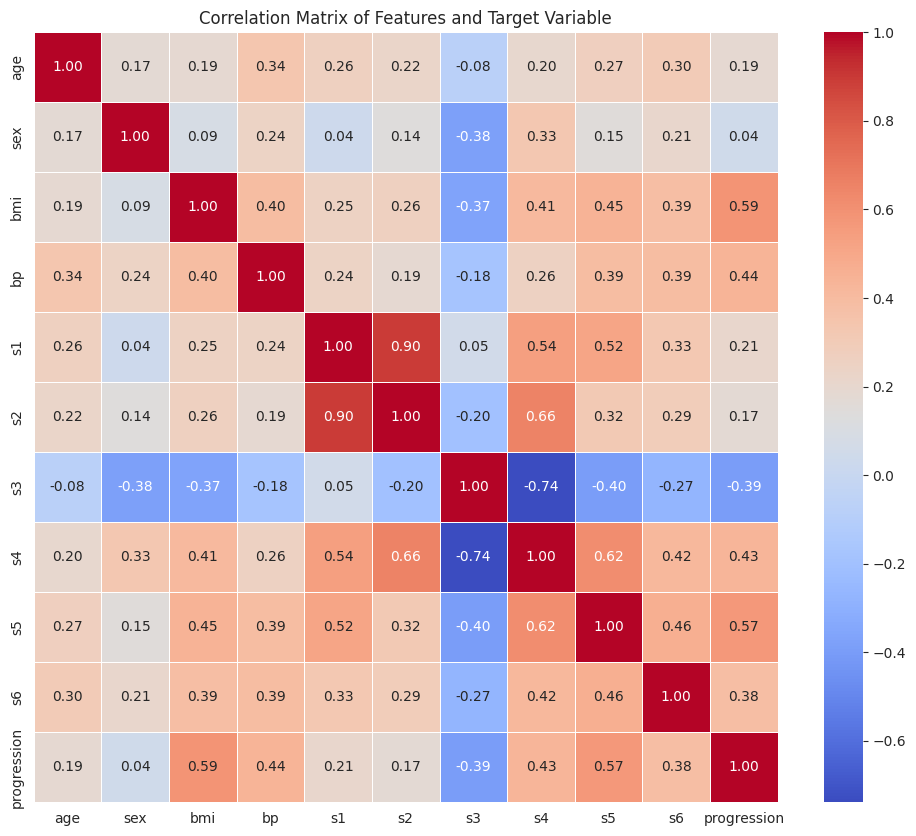

In [6]:
# Visualize relationships between features and the target variable using scatter plots
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(20, 15))
axes = axes.flatten()

for i, col in enumerate(X_scaled.columns):
    sns.scatterplot(x=X_scaled[col], y=y, ax=axes[i], alpha=0.6)
    axes[i].set_title(f'{col} vs. Progression')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Progression')

# Remove any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('Feature vs. Target Variable Relationships', y=1.02, fontsize=18)
plt.show()

# Display correlation matrix
plt.figure(figsize=(12, 10))
correlation_matrix = pd.concat([X_scaled, y], axis=1).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Features and Target Variable')
plt.show()

## 3. Building the ANN Model

In [7]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Define the ANN architecture
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_scaled.shape[1],)), # Input layer and first hidden layer
    Dense(32, activation='relu'), # Second hidden layer
    Dense(1) # Output layer (single neuron for regression, no activation for linear output)
])

# Display the model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,817 (11.00 KB)

 Trainable params: 2,817 (11.00 KB)

 Non-trainable params: 0 (0.00 B)

## 4. Training the ANN Model

### Split the dataset into training and testing sets

In [8]:
from sklearn.model_selection import train_test_split

# Split the scaled features and target variable into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (353, 10)
X_test shape: (89, 10)
y_train shape: (353,)
y_test shape: (89,)


### Compile and Train the Model

Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - loss: 31276.4473 - val_loss: 22193.1699
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 31042.7559 - val_loss: 21996.5605
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 30781.0781 - val_loss: 21774.3926
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 30474.8477 - val_loss: 21510.8965
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 30095.9141 - val_loss: 21189.0273
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 29609.9434 - val_loss: 20790.2012
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 29005.2832 - val_loss: 20304.7598
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 28264.7344 - val_loss: 19713.8652
Epoch 9/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 27312.0645 - val_loss: 19019.5039
Epoch 10/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 26209.4492 - val_loss: 18195.0039
Epoch 11/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 24902.2559 - val_los

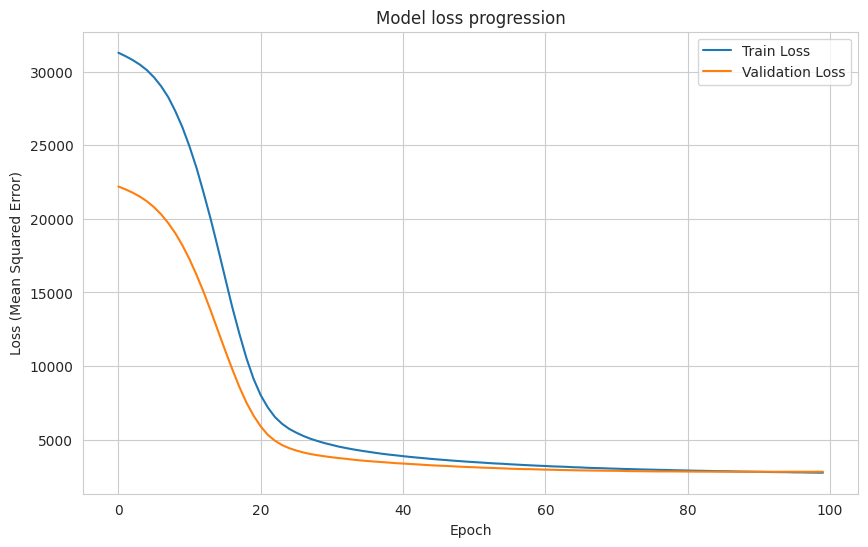

In [9]:
# Compile the model
# Using 'mean_squared_error' as loss function for regression and 'adam' optimizer
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
# Using 100 epochs and a batch size of 32 for training
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2, verbose=1)

# Plot training & validation loss values
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model loss progression')
plt.ylabel('Loss (Mean Squared Error)')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.show()

## 5. Evaluating the Model

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Mean Squared Error on Test Set: 2982.35
R2 Score on Test Set: 0.44


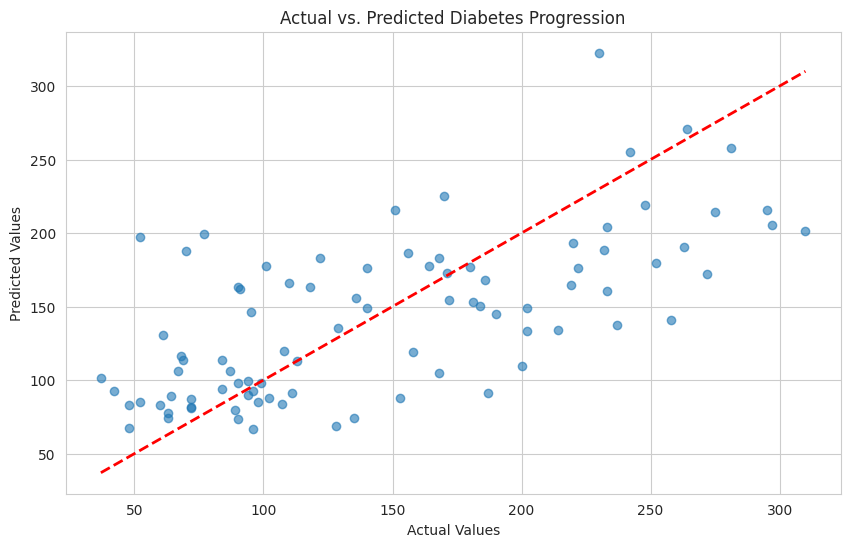

In [10]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Make predictions on the test set
y_pred = model.predict(X_test).flatten()

# Calculate Mean Squared Error
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error on Test Set: {mse:.2f}')

# Calculate R2 Score
r2 = r2_score(y_test, y_pred)
print(f'R2 Score on Test Set: {r2:.2f}')

# Visualize predictions vs. actual values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Diagonal line
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Diabetes Progression')
plt.show()

## 6. Improving the Model

### Experiment 1: Adding more layers and neurons

In [11]:
from tensorflow.keras.layers import Dropout

# Define an improved ANN architecture
# Added more layers, increased neurons, and included Dropout for regularization
model_improved = Sequential([
    Dense(128, activation='relu', input_shape=(X_scaled.shape[1],)),
    Dropout(0.3), # Added dropout layer
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1)
])

model_improved.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,777 (46.00 KB)

 Trainable params: 11,777 (46.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - loss: 31305.4707 - val_loss: 22152.5430
Epoch 2/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 30948.8086 - val_loss: 21751.1836
Epoch 3/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 30325.8340 - val_loss: 21035.2578
Epoch 4/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 29217.8359 - val_loss: 19827.6680
Epoch 5/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 27293.2402 - val_loss: 17922.5605
Epoch 6/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 24262.7695 - val_loss: 15148.8350
Epoch 7/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 19743.8887 - val_loss: 11495.0312
Epoch 8/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 14184.6260 - val_loss: 7587.4663
Epoch 9/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 9280.8730 - val_loss: 4741.8086
Epoch 10/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 6083.0962 - val_loss: 3888.2358
Epoch 11/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 5873.4912 - val_loss: 368

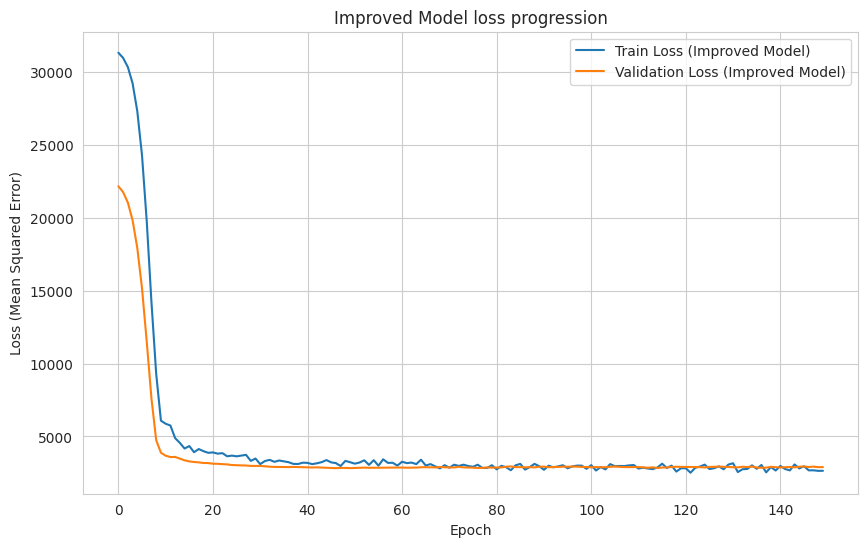

In [12]:
# Compile the improved model
model_improved.compile(optimizer='adam', loss='mean_squared_error')

# Train the improved model
history_improved = model_improved.fit(X_train, y_train, epochs=150, batch_size=32, validation_split=0.2, verbose=1)

# Plot training & validation loss values for the improved model
plt.figure(figsize=(10, 6))
plt.plot(history_improved.history['loss'], label='Train Loss (Improved Model)')
plt.plot(history_improved.history['val_loss'], label='Validation Loss (Improved Model)')
plt.title('Improved Model loss progression')
plt.ylabel('Loss (Mean Squared Error)')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.show()

### Evaluate the Improved Model

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Mean Squared Error on Test Set (Improved Model): 2740.16
R2 Score on Test Set (Improved Model): 0.48

Original Model MSE: 2982.35, R2 Score: 0.44
Improved Model MSE: 2740.16, R2 Score: 0.48


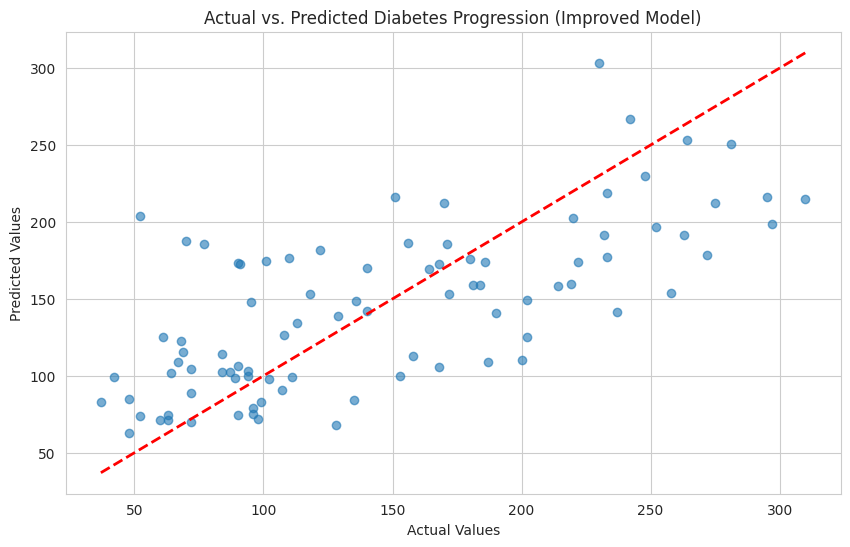

In [13]:
# Make predictions on the test set using the improved model
y_pred_improved = model_improved.predict(X_test).flatten()

# Calculate Mean Squared Error for the improved model
mse_improved = mean_squared_error(y_test, y_pred_improved)
print(f'Mean Squared Error on Test Set (Improved Model): {mse_improved:.2f}')

# Calculate R2 Score for the improved model
r2_improved = r2_score(y_test, y_pred_improved)
print(f'R2 Score on Test Set (Improved Model): {r2_improved:.2f}')

# Compare with original model's performance
print(f'\nOriginal Model MSE: {mse:.2f}, R2 Score: {r2:.2f}')
print(f'Improved Model MSE: {mse_improved:.2f}, R2 Score: {r2_improved:.2f}')

# Visualize predictions vs. actual values for improved model
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_improved, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Diabetes Progression (Improved Model)')
plt.show()

## 5. Evaluating the Model

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Mean Squared Error on Test Set: 2982.35
R2 Score on Test Set: 0.44


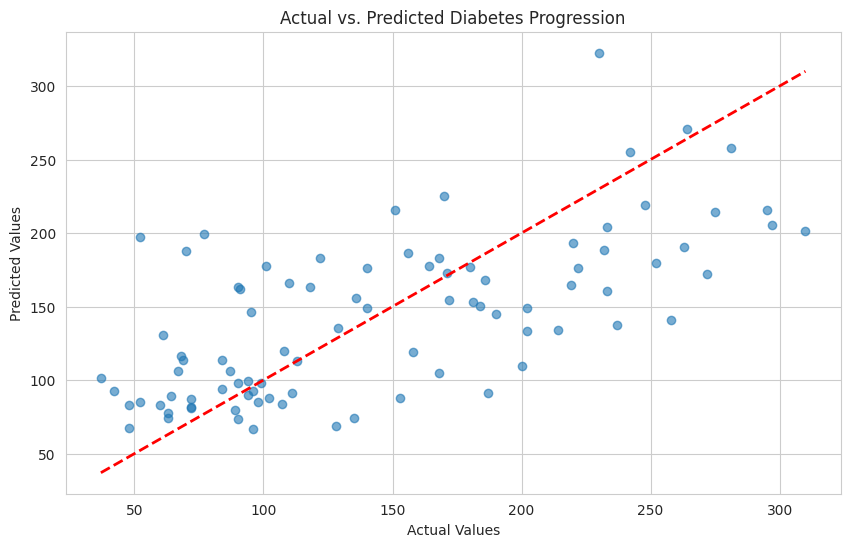

In [14]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Make predictions on the test set
y_pred = model.predict(X_test).flatten()

# Calculate Mean Squared Error
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error on Test Set: {mse:.2f}')

# Calculate R2 Score
r2 = r2_score(y_test, y_pred)
print(f'R2 Score on Test Set: {r2:.2f}')

# Visualize predictions vs. actual values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Diagonal line
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Diabetes Progression')
plt.show()